In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler # Z-score

# Limpeza e Pré-processamento

In [38]:
# Carregando a base de dados
df = pd.read_csv('email_phishing_data.csv')

print(f"Tamanho original do dataset: {df.shape}")
df.head()

Tamanho original do dataset: (524846, 9)


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


In [39]:
# Removendo duplicatas
df = df.drop_duplicates()
print(f"Tamanho após remover duplicatas: {df.shape}")

Tamanho após remover duplicatas: (205052, 9)


In [40]:
# Removendo features redundantes
colunas_redundantes = ['num_stopwords', 'num_unique_domains'] 
df = df.drop(columns=colunas_redundantes, errors='ignore')
df.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,0,0,0,0,0
1,5,5,0,0,0,0,0
2,34,32,0,0,0,0,0
3,6,6,0,0,0,0,0
4,9,9,0,0,0,0,0


In [41]:
# Separando features e target
X = df.drop('label', axis=1)
y = df['label']

X.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,140,94,0,0,0,0
1,5,5,0,0,0,0
2,34,32,0,0,0,0
3,6,6,0,0,0,0
4,9,9,0,0,0,0


Cross-validation e Normalização

In [42]:
# Cross-validation
k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Normalização (StandardScaler = z-score)
scaler = StandardScaler()
fold = 1
dados_preparados = []

for train_index, test_index in skf.split(X, y):   
    # Separando os dados de treino e teste para o fold atual
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Normalização
    # (fit_transform) -> Calculando média e desvio padrão SOMENTE no conjunto de treino
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Aplicando a Normalização (transform) no conjunto de teste
    X_test_scaled = scaler.transform(X_test)

    # Guardando os dados prontos para posterior treinamento e avaliação do modelo
    dados_preparados.append({
        'fold': fold,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test
    })
        
    fold += 1

print(f"Pré-processamento concluído! {len(dados_preparados)} folds estão prontos para uso.")

# Vamos usar a primeira coluna (feature) como exemplo
nome_feature = X.columns[0]

# Exibindo resultado da normalizacão na feature "num_words"
print(f"\n--- Efeito da Normalização na feature: '{nome_feature}' ---")

# Estatísticas ANTES da normalização (usando o X original)
print("\n[ANTES] (Valores brutos da base original):")
print(f"Média         : {X[nome_feature].mean():.2f}")
print(f"Desvio Padrão : {X[nome_feature].std():.2f}")
print(f"Valor Máximo  : {X[nome_feature].max():.2f}") 


# Estatísticas DEPOIS da normalização (usando o Fold 1 preparado)
X_treino_norm = dados_preparados[0]['X_train']
print("\n[DEPOIS] (Valores transformados com Z-Score no Fold 1):")
print(f"Média         : {X_treino_norm[:, 0].mean():.2f}")
print(f"Desvio Padrão : {X_treino_norm[:, 0].std():.2f}")
print(f"Valor Máximo  : {X_treino_norm[:, 0].max():.2f}")


Pré-processamento concluído! 10 folds estão prontos para uso.

--- Efeito da Normalização na feature: 'num_words' ---

[ANTES] (Valores brutos da base original):
Média         : 344.90
Desvio Padrão : 5255.02
Valor Máximo  : 2339682.00

[DEPOIS] (Valores transformados com Z-Score no Fold 1):
Média         : 0.00
Desvio Padrão : 1.00
Valor Máximo  : 422.87


# KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

valores_k = [1, 3, 5, 7, 9, 11, 13, 15]
metricas = ['euclidean', 'manhattan']


In [46]:
resultados = []

for metrica in metricas:
    for k in valores_k:

        accs, precs, recalls, f1s = [], [], [], []

        for pacote in dados_preparados:

            X_treino = pacote['X_train']
            y_treino = pacote['y_train']
            X_teste = pacote['X_test']
            y_teste = pacote['y_test']

            modelo = KNeighborsClassifier(n_neighbors=k, metric=metrica)
            modelo.fit(X_treino, y_treino)

            y_pred = modelo.predict(X_teste)

            accs.append(accuracy_score(y_teste, y_pred))
            precs.append(precision_score(y_teste, y_pred, average='weighted'))
            recalls.append(recall_score(y_teste, y_pred, average='weighted'))
            f1s.append(f1_score(y_teste, y_pred, average='weighted'))

        resultados.append({
            'Metrica': metrica,
            'K': k,
            'Accuracy': np.mean(accs),
            'Precision': np.mean(precs),
            'Recall': np.mean(recalls),
            'F1': np.mean(f1s),
            'Accuracy_std': np.std(accs),
            'F1_std': np.std(f1s)
        })

In [47]:
df = pd.DataFrame(resultados)

df.sort_values(
    by='F1',
    ascending=False
).head(10)

,Metrica,K,Accuracy,Precision,Recall,F1,Accuracy_std,F1_std
9,manhattan,3,0.968901,0.956253,0.968901,0.959836,0.000405,0.001023
1,euclidean,3,0.968827,0.956055,0.968827,0.959714,0.000491,0.001016
10,manhattan,5,0.970169,0.957585,0.970169,0.959342,0.000475,0.001242
2,euclidean,5,0.970086,0.957249,0.970086,0.959202,0.000413,0.001200
11,manhattan,7,0.970588,0.958817,0.970588,0.958887,0.000506,0.001260
3,euclidean,7,0.970593,0.958794,0.970593,0.958783,0.000684,0.001390
12,manhattan,9,0.970744,0.959916,0.970744,0.958395,0.000490,0.001232
4,euclidean,9,0.970685,0.959555,0.970685,0.958206,0.000444,0.001166
13,manhattan,11,0.970739,0.960483,0.970739,0.957864,0.000439,0.001049
5,euclidean,11,0.970568,0.958899,0.970568,0.957540,0.000442,0.001133


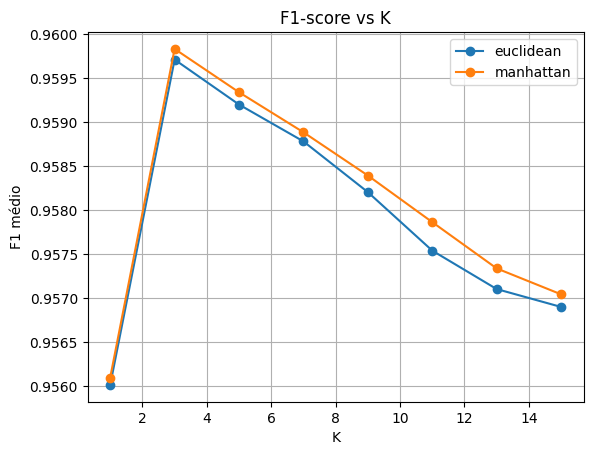

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(resultados)

plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['F1'], marker='o', label=metrica)

plt.title("F1-score vs K")
plt.xlabel("K")
plt.ylabel("F1 médio")
plt.legend()
plt.grid(True)
plt.show()

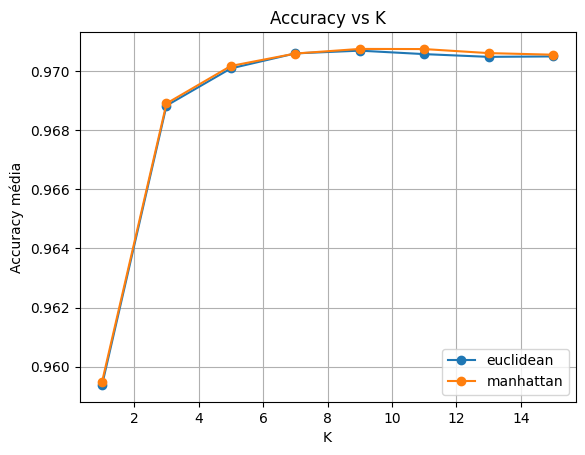

In [49]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['Accuracy'], marker='o', label=metrica)

plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy média")
plt.legend()
plt.grid(True)
plt.show()

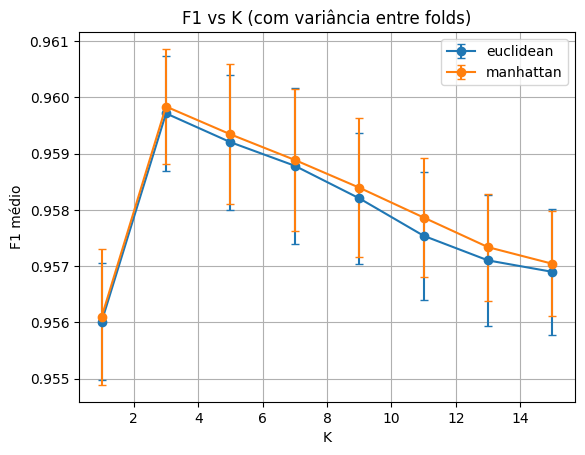

In [ ]:
plt.figure()

for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]

    plt.errorbar(
        subset['K'],
        subset['F1'],
        yerr=subset['F1_std'],
        marker='o',
        capsize=3,
        label=metrica
    )

plt.title("F1 vs K (com variância entre folds)")
plt.xlabel("K")
plt.ylabel("F1 médio")
plt.legend()
plt.grid(True)
plt.show()

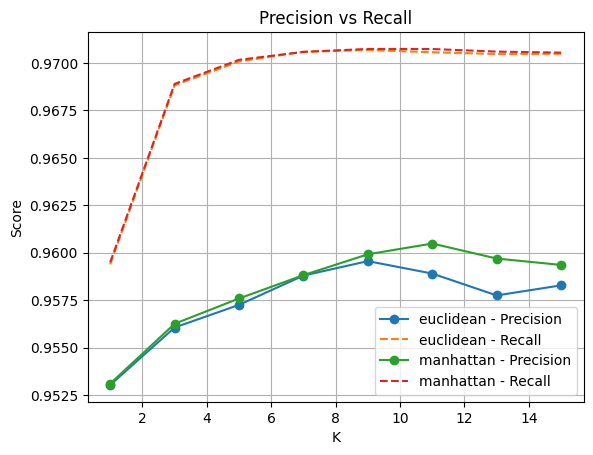

In [51]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['Precision'], marker='o', label=f"{metrica} - Precision")
    plt.plot(subset['K'], subset['Recall'], linestyle='--', label=f"{metrica} - Recall")

plt.title("Precision vs Recall")
plt.xlabel("K")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## Árvores de Decisão e Random Forest

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

resultados_dt = []
resultados_rf = []

for pacote in dados_preparados:
    X_train, y_train = pacote['X_train'], pacote['y_train']
    X_test, y_test = pacote['X_test'], pacote['y_test']
    
    # Treino DT
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    
    # Treino RF
    rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    # Armazenar resultados DT
    resultados_dt.append({
        'fold': pacote['fold'], 
        'Accuracy': accuracy_score(y_test, y_pred_dt), 
        'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
        'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
        'F1': f1_score(y_test, y_pred_dt, average='weighted')
    })
    
    # Armazenar resultados RF
    resultados_rf.append({
        'fold': pacote['fold'], 
        'Accuracy': accuracy_score(y_test, y_pred_rf), 
        'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
        'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
        'F1': f1_score(y_test, y_pred_rf, average='weighted')
    })

df_dt = pd.DataFrame(resultados_dt)
df_rf = pd.DataFrame(resultados_rf)
df_dt['modelo'] = 'Decision Tree'
df_rf['modelo'] = 'Random Forest'
df_completo = pd.concat([df_dt, df_rf])

In [60]:
# Calculando a média e o desvio padrão
tabela_media = df_completo.groupby('modelo')[['Accuracy', 'Precision', 'Recall', 'F1']].mean()
tabela_std = df_completo.groupby('modelo')[['Accuracy', 'F1']].std().rename(columns={'Accuracy': 'Accuracy_std', 'F1': 'F1_std'})

# Unindo as tabelas
tabela_final = pd.concat([tabela_media, tabela_std], axis=1)
display(tabela_final)

,Accuracy,Precision,Recall,F1,Accuracy_std,F1_std
modelo,,,,,,
Decision Tree,0.969062,0.958066,0.969062,0.961160,0.000818,0.000902
Random Forest,0.971554,0.965419,0.971554,0.959709,0.000346,0.000611


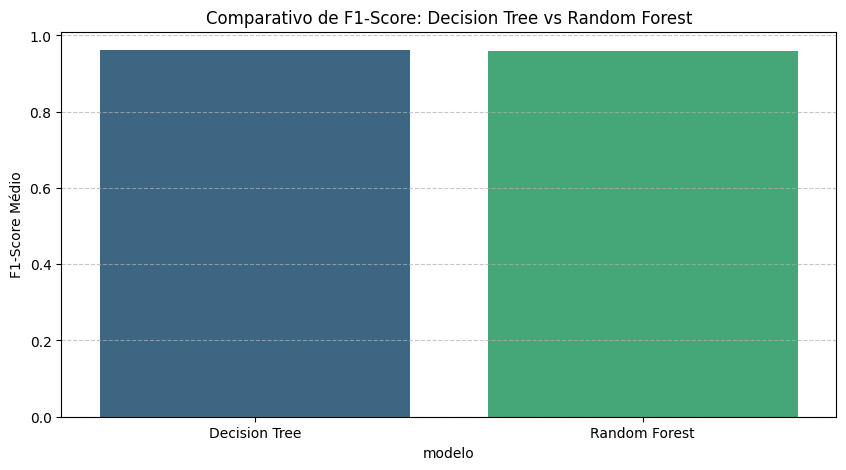

In [61]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_completo, x='modelo', y='F1', hue='modelo', palette='viridis', legend=False)
plt.title('Comparativo de F1-Score: Decision Tree vs Random Forest')
plt.ylabel('F1-Score Médio')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

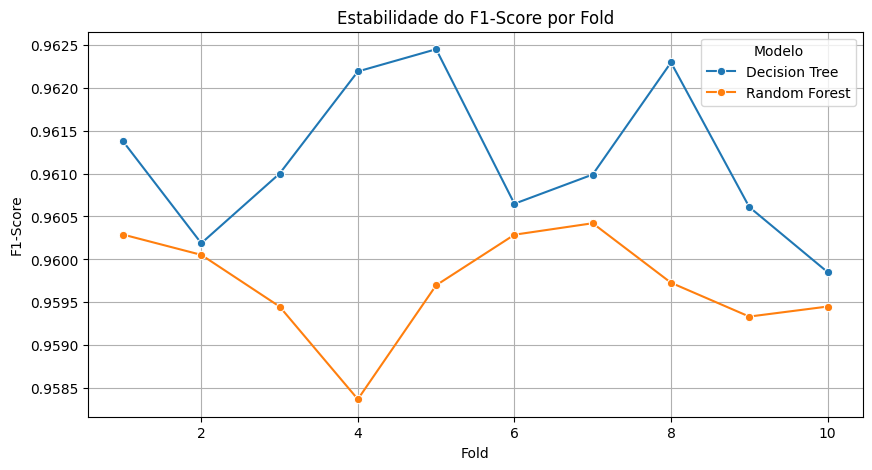

In [62]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_completo, x='fold', y='F1', hue='modelo', marker='o')
plt.title('Estabilidade do F1-Score por Fold')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.grid(True)
plt.legend(title='Modelo')
plt.show()

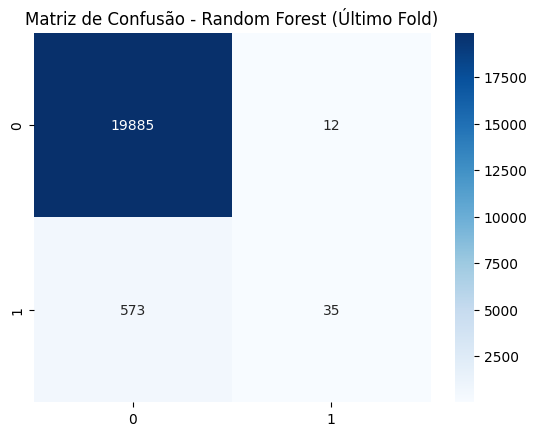

In [63]:
# Usando o último fold como exemplo
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest (Último Fold)')
plt.show()

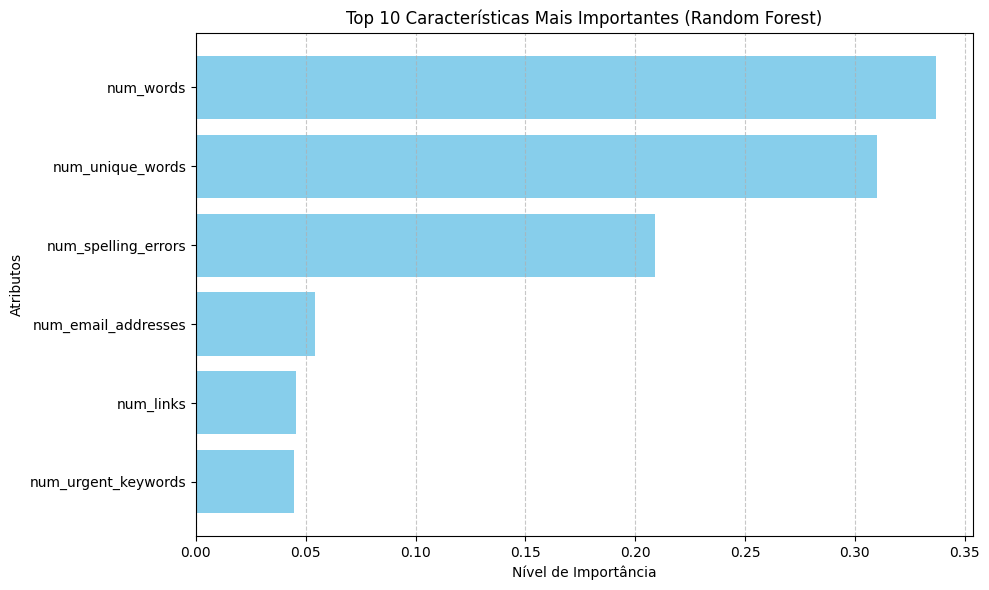

In [64]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')

# Utilizando a variável X original para resgatar os nomes das features
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])

plt.title('Top 10 Características Mais Importantes (Random Forest)')
plt.xlabel('Nível de Importância')
plt.ylabel('Atributos')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()